## SUPPORT VECTOR MACHINE (SVM) CLASSIFICATION

In [3]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
accuracy_score, confusion_matrix,classification_report)

### Step 2: Load Dataset

In [4]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)
print("Dataset Shape:",X.shape)
print(X.head(10))

Dataset Shape: (569, 30)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   
5        12.45         15.70           82.57      477.1          0.12780   
6        18.25         19.98          119.60     1040.0          0.09463   
7        13.71         20.83           90.20      577.9          0.11890   
8        13.00         21.82           87.50      519.8          0.12730   
9        12.46         24.04           83.97      475.9          0.11860   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760         0.30010              0.14710       

### Step 3: Check Dataset Information

In [5]:
print("\nDataset Information")
print(X.info())


Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error

In [6]:
X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


### Step 4: Check Missing Values

In [7]:
print("\nMissing Values")
print(X.isnull().sum())


Missing Values
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [8]:
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### Step 5: Train Test Split

In [9]:
X_train ,X_test ,y_train ,y_test = train_test_split (
    X,y,test_size=0.2, random_state = 42, stratify=y )

print("\nTraining Data Shape:" , X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [10]:
(X.columns)

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

### Step 6: Feature Scaling

In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Step 7: Create SVM Model

In [13]:
svm_model = SVC(
    kernel = 'linear' , 
    C=1.0,
    random_state=42
)

In [14]:
print(X_train_scaled)

[[-1.07200079 -0.6584246  -1.0880801  ... -1.35052668 -0.35265805
  -0.54138003]
 [ 1.74874285  0.06650173  1.75115682 ...  1.54991557  0.19107787
  -0.1737386 ]
 [-0.97473376 -0.93112416 -0.99770871 ... -1.70744192 -0.307734
  -1.21303263]
 ...
 [ 0.39844772  1.06867262  0.50751384 ...  1.53492543  0.16164487
   1.23754763]
 [ 0.85331409 -0.0380331   0.9054796  ...  2.10455077  0.31035897
   0.36249578]
 [-0.91179628 -0.82431683 -0.87666079 ... -0.51332734 -0.50756857
   1.30824791]]


### Step 8: Train Model

In [15]:
svm_model.fit(X_train_scaled ,y_train)
print("\nModel Training Completed")


Model Training Completed


### Step 9: Predictions

In [16]:
y_pred = svm_model.predict(X_test_scaled)

print("\nPredictionss")
print(y_pred[:10])


Predictionss
[0 1 0 0 0 1 1 0 0 0]


### Step 10: Accuracy

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score")
print(round(accuracy,4))


Accuracy Score
0.9737


### Step 11: Confusion Matrix

In [18]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)


Confusion Matrix
[[41  1]
 [ 2 70]]


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

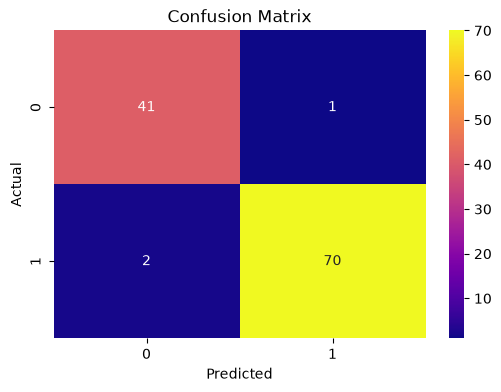

In [25]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='plasma')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Step 12: Classification Report

In [26]:
report = classification_report(y_test , y_pred)
print("\nClassification Report")
print(report)


Classification Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



### Step 13: RBF Kernel SVM

In [30]:
rbf_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42,
    verbose=1
)

rbf_model.fit(X_train_scaled, y_train)

rbf_pred = rbf_model.predict(X_test_scaled)

rbf_accuracy = accuracy_score(y_test, rbf_pred)

print("\nRBF Kernel Accuracy")
print(round(rbf_accuracy,4))

[LibSVM]
RBF Kernel Accuracy
0.9825


### Step 14: Compare Models

In [31]:
print("\nModel Comparison")
print("Linear Kernel Accuracy :", accuracy)
print("RBF Kernel Accuracy    :", rbf_accuracy)


Model Comparison
Linear Kernel Accuracy : 0.9736842105263158
RBF Kernel Accuracy    : 0.9824561403508771


### Step 15: Hyperparameter Tuning

In [35]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}
grid_search = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    verbose=1)
grid_search.fit(X_train_scaled, y_train)
print("\nBest Parameters")
print(grid_search.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits

Best Parameters
{'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


### Step 16: Best Model Evaluation

In [ ]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test_scaled)

best_accuracy = accuracy_score(y_test ,